# Solver UN a 3 equazioni con metodo spettrale Sciantix

Questo notebook risolve il sistema per il gas in soluzione `c`, il gas in bolle bulk `m_b` e il gas in bolle su dislocazioni `m_d` usando lo schema del solver Sciantix `SpectralDiffusion3equationsExchange` descritto in `UNcode.md`.

Le correlazioni fisiche sono quelle riportate in `UNmodel.md`, con una nota: per riprodurre il codice Sciantix il denominatore del sink da dislocazioni usa `-3/5`, come in `src/classes/System.C`, non `-5/3`.

Il codice sotto usa solo la libreria standard Python. `matplotlib` è opzionale: se non è installato, il solver gira comunque e stampa i risultati.

Rates used by the Sciantix-style 3x3 solver
                D1 = 4.293480e-19
                D2 = 0.000000e+00
                D3 = 1.850000e-19
                Dg = 6.143480e-19
              beta = 2.400000e+19
               g_b = 9.341351e-05
               g_d = 3.346932e-05
               b_b = 2.406349e-05
               b_d = 2.406349e-05
               den = 3.486670e+00
  free_dislocation = 2.992800e+13

Final concentrations
c   = 4.379531e+23 at/m3
m_b = 1.123760e+24 at/m3
m_d = 4.026343e+23 at/m3
sum = 1.964347e+24 at/m3


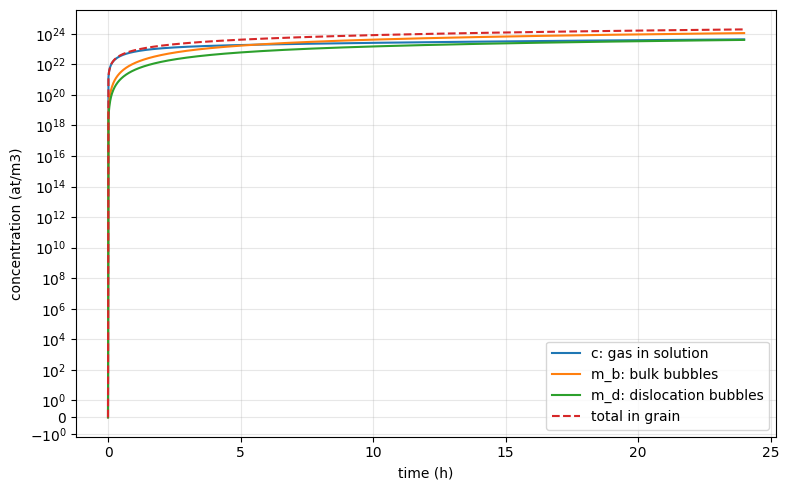

In [1]:
import math
from dataclasses import dataclass

try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    plt = None


@dataclass
class UNParameters:
    # Operating conditions
    temperature: float = 1600.0              # K
    fission_rate: float = 1.0e20             # fiss / (m3 s)
    grain_radius: float = 5.0e-6             # m
    final_time: float = 24.0 * 3600.0        # s
    dt: float = 60.0                         # s
    n_modes: int = 40                        # Sciantix default

    # Gas production: beta = yield * fission_rate
    xe_yield: float = 0.24                   # atoms / fission, as in SetSystem.C for Xe in UN
    precursor_factor: float = 1.0            # Xe stable gas

    # Xe diffusivity in UN, Rizk / UNmodel.md
    D10: float = 1.56e-3                     # m2/s
    Q1: float = 4.94                         # eV
    A20: float = 1.21e-67                    # m(7/2) / s(1/2)
    B21: float = 25.87                       # eV
    B22: float = -1.49                       # eV2
    B23: float = 0.0                         # eV3
    A30: float = 1.85e-39                    # m5
    kB: float = 8.617333262e-5               # eV/K
    use_sciantix_D2_zero: bool = True        # Sciantix UN code sets D2 = 0 for Xe

    # Bubble / dislocation geometry
    radius_in_lattice: float = 0.21e-9       # m
    R_b: float = 1.0e-9                      # m, bulk bubble radius without lattice offset
    N_b: float = 1.0e22                      # bub/m3, example value
    R_d: float = 1.0e-9                      # m, dislocation bubble radius without lattice offset
    N_d: float = 3.6e19                      # bub/m3, from UNmodel.md
    rho_d: float = 3.0e13                    # 1/m2
    r_d: float = 3.46e-10                    # m
    Z_d: float = 5.0

    # Scaling factors, kept explicit to mirror Sciantix
    diffusivity_sf: float = 1.0
    trapping_sf: float = 1.0
    resolution_sf: float = 1.0

    # Initial volume-averaged gas concentrations
    c0: float = 0.0                          # at/m3
    mb0: float = 0.0                         # at/m3
    md0: float = 0.0                         # at/m3


def xe_diffusivity_UN(p):
    T = p.temperature
    F = p.fission_rate
    kBT = p.kB * T
    D1 = p.D10 * math.exp(-p.Q1 / kBT)
    if p.use_sciantix_D2_zero:
        D2 = 0.0
    else:
        D2 = p.A20 * math.sqrt(F) * math.exp(-p.B21 / kBT - p.B22 / kBT**2 - p.B23 / kBT**3)
    D3 = p.A30 * F
    Dg = (D1 + D2 + D3) * p.diffusivity_sf * p.precursor_factor
    return Dg, {"D1": D1, "D2": D2, "D3": D3, "Dg": Dg}


def b0_resolution(R):
    return 1.0e-25 * (2.64 - 2.02 * math.exp(-2.61e-9 / R))


def resolution_rates_UN(p):
    Rb_eff = p.R_b + p.radius_in_lattice
    Rd_eff = p.R_d + p.radius_in_lattice
    b_b = p.fission_rate * b0_resolution(Rb_eff) * p.resolution_sf
    b_d = p.fission_rate * b0_resolution(Rd_eff) * p.resolution_sf
    return b_b, b_d


def trapping_rates_UN(p, Dg):
    Rb_eff = p.R_b + p.radius_in_lattice
    Rd_eff = p.R_d + p.radius_in_lattice
    g_b = 0.0 if p.N_b == 0.0 else 4.0 * math.pi * Dg * Rb_eff * p.N_b

    Gamma_d = 1.0 / math.sqrt(math.pi * p.rho_d)
    den = math.log(Gamma_d / (p.Z_d * p.r_d)) - 3.0 / 5.0
    if den <= 0.0:
        raise ValueError(f"Invalid dislocation sink denominator: {den:g}")

    free_dislocation = max(p.rho_d - 2.0 * p.R_d * p.N_d, 0.0)
    term_bubbles = 4.0 * math.pi * Dg * Rd_eff * p.N_d
    term_dislocation = (2.0 * math.pi * Dg / den) * free_dislocation
    g_d = term_bubbles + term_dislocation

    return p.trapping_sf * g_b, p.trapping_sf * g_d, {
        "Gamma_d": Gamma_d,
        "den": den,
        "free_dislocation": free_dislocation,
        "term_bubbles": term_bubbles,
        "term_dislocation": term_dislocation,
    }


def beta_production(p):
    return p.xe_yield * p.fission_rate


def initialize_modes_from_average(average, n_modes, n_iter=20):
    # Same iterative projection pattern used by Sciantix initialization.
    modes = [0.0 for _ in range(n_modes)]
    projection_coeff = -math.sqrt(8.0 / math.pi)
    remainder = average
    for _ in range(n_iter):
        reconstructed = 0.0
        for i in range(n_modes):
            n = i + 1
            n_coeff = (-1.0) ** n / n
            modes[i] += projection_coeff * n_coeff * remainder
            reconstructed += projection_coeff * n_coeff * modes[i] * 3.0 / (4.0 * math.pi)
        remainder = average - reconstructed
    return modes


def reconstruct_average(modes):
    projection_coeff = -2.0 * math.sqrt(2.0 / math.pi)
    average = 0.0
    for i, value in enumerate(modes):
        n = i + 1
        n_coeff = (-1.0) ** n / n
        average += projection_coeff * n_coeff * value / ((4.0 / 3.0) * math.pi)
    return average


def det3(A):
    return (
        A[0][0] * (A[1][1] * A[2][2] - A[1][2] * A[2][1])
        - A[0][1] * (A[1][0] * A[2][2] - A[1][2] * A[2][0])
        + A[0][2] * (A[1][0] * A[2][1] - A[1][1] * A[2][0])
    )


def solve3x3_cramer(A, b):
    # Cramer's rule, equivalent to Sciantix Solver::Laplace3x3.
    detA = det3(A)
    if detA == 0.0:
        raise ZeroDivisionError("Singular 3x3 system in spectral mode solve")
    Ax = [[b[i], A[i][1], A[i][2]] for i in range(3)]
    Ay = [[A[i][0], b[i], A[i][2]] for i in range(3)]
    Az = [[A[i][0], A[i][1], b[i]] for i in range(3)]
    return [det3(Ax) / detA, det3(Ay) / detA, det3(Az) / detA]


def sciantix_3x3_exchange_step(modes_c, modes_mb, modes_md, Dg, R, beta, g_b, g_d, b_b, b_d, dt):
    projection_coeff = -2.0 * math.sqrt(2.0 / math.pi)
    diffusion_rate_coeff = math.pi**2 * Dg / R**2

    for i in range(len(modes_c)):
        n = i + 1
        n_coeff = (-1.0) ** n / n
        diffusion_rate = diffusion_rate_coeff * n**2
        source_rate = projection_coeff * beta * n_coeff

        A = [
            [1.0 + (diffusion_rate + g_b + g_d) * dt, -b_b * dt, -b_d * dt],
            [-g_b * dt, 1.0 + b_b * dt, 0.0],
            [-g_d * dt, 0.0, 1.0 + b_d * dt],
        ]
        rhs = [modes_c[i] + source_rate * dt, modes_mb[i], modes_md[i]]
        modes_c[i], modes_mb[i], modes_md[i] = solve3x3_cramer(A, rhs)

    return reconstruct_average(modes_c), reconstruct_average(modes_mb), reconstruct_average(modes_md)


def solve_UN_sciantix(p):
    Dg, D_parts = xe_diffusivity_UN(p)
    b_b, b_d = resolution_rates_UN(p)
    g_b, g_d, trapping_parts = trapping_rates_UN(p, Dg)
    beta = beta_production(p)

    modes_c = initialize_modes_from_average(p.c0, p.n_modes)
    modes_mb = initialize_modes_from_average(p.mb0, p.n_modes)
    modes_md = initialize_modes_from_average(p.md0, p.n_modes)

    n_steps = int(math.ceil(p.final_time / p.dt))
    times = [0.0]
    c = [reconstruct_average(modes_c)]
    mb = [reconstruct_average(modes_mb)]
    md = [reconstruct_average(modes_md)]

    for _ in range(n_steps):
        dt = min(p.dt, p.final_time - times[-1])
        if dt <= 0.0:
            break
        c_new, mb_new, md_new = sciantix_3x3_exchange_step(
            modes_c, modes_mb, modes_md, Dg, p.grain_radius, beta, g_b, g_d, b_b, b_d, dt
        )
        times.append(times[-1] + dt)
        c.append(c_new)
        mb.append(mb_new)
        md.append(md_new)

    rates = {
        "Dg": Dg,
        "beta": beta,
        "g_b": g_b,
        "g_d": g_d,
        "b_b": b_b,
        "b_d": b_d,
        **D_parts,
        **trapping_parts,
    }
    return times, c, mb, md, rates


# Example run. Change these values to match a specific Sciantix case.
p = UNParameters(
    temperature=1600.0,
    fission_rate=1.0e20,
    grain_radius=5.0e-6,
    final_time=24.0 * 3600.0,
    dt=60.0,
    R_b=1.0e-9,
    N_b=1.0e22,
    R_d=1.0e-9,
    N_d=3.6e19,
    c0=0.0,
    mb0=0.0,
    md0=0.0,
)

times, c, mb, md, rates = solve_UN_sciantix(p)

print("Rates used by the Sciantix-style 3x3 solver")
for key in ["D1", "D2", "D3", "Dg", "beta", "g_b", "g_d", "b_b", "b_d", "den", "free_dislocation"]:
    print(f"{key:>18s} = {rates[key]:.6e}")

print("\nFinal concentrations")
print(f"c   = {c[-1]:.6e} at/m3")
print(f"m_b = {mb[-1]:.6e} at/m3")
print(f"m_d = {md[-1]:.6e} at/m3")
print(f"sum = {(c[-1] + mb[-1] + md[-1]):.6e} at/m3")

if plt is not None:
    hours = [t / 3600.0 for t in times]
    total = [ci + mbi + mdi for ci, mbi, mdi in zip(c, mb, md)]
    plt.figure(figsize=(8, 5))
    plt.plot(hours, c, label="c: gas in solution")
    plt.plot(hours, mb, label="m_b: bulk bubbles")
    plt.plot(hours, md, label="m_d: dislocation bubbles")
    plt.plot(hours, total, "--", label="total in grain")
    plt.xlabel("time (h)")
    plt.ylabel("concentration (at/m3)")
    plt.yscale("symlog", linthresh=1.0)
    plt.grid(True, which="both", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("\nmatplotlib is not installed in this environment: skipping plot.")
